# Paper figures

One section per figure. Every figure is written to `figures/` as a vector PDF
(for the manuscript) and a 300 dpi PNG (for slides and previews).

Every figure uses topsoil samples (0–30 cm) only: Al Moutmir sampled only that layer, and
Fertimap's subsoil samples (30–60 cm) are left out so that every comparison is like with like.

Run with the `explore` pixi environment (`pixi run -e explore notebook`, or pick
`.pixi/envs/explore` as the kernel): it is the one that carries geopandas.

In [86]:
import os
import sys
from pathlib import Path

# A kernel started straight from the pixi env skips its activation script, which is what
# normally points GDAL at PROJ's database; without it, reading any .prj file fails.
os.environ.setdefault("PROJ_DATA", str(Path(sys.prefix) / "share" / "proj"))

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Polygon, Rectangle
from matplotlib.ticker import StrMethodFormatter
from PIL import Image
from scipy.spatial import cKDTree
from shapely import contains_xy, prepare
from shapely.geometry import box

DATASET_CSV = Path(
    "/home/kmisbah/CESBIO/AL_Moutmir/Soil_Datasets/soil_dataset_20251118_140815/"
    "Morocco_soil_analysis_filtered_uuid_roadsafe.csv"
)
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# Shared ink and chrome, reused by every figure below.
INK = "#0b0b0b"
INK_2 = "#52514e"
MUTED = "#898781"
GRID = "#e1e0d9"
BASELINE = "#c3c2b7"
EMPTY_BAND = "#f0efec"

# Samples dated before 2017 come from Fertimap; from 2017 onwards, Al Moutmir.
AL_MOUTMIR_START_YEAR = 2017
PROJECT_COLORS = {"Fertimap": "#2a78d6", "Al Moutmir": "#eb6834"}
# Paler steps of Fertimap's blue, for figures where it is context and Al Moutmir is the focus.
FERTIMAP_TINT = "#86b6ef"
FERTIMAP_AREA_FILL = "#b7d3f6"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.labelcolor": INK_2,
    "axes.edgecolor": BASELINE,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "axes.axisbelow": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "xtick.color": BASELINE,
    "ytick.color": BASELINE,
    "xtick.labelcolor": INK_2,
    "ytick.labelcolor": INK_2,
    "ytick.major.size": 0,
    "legend.frameon": False,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,  # embed TrueType so text stays editable in the PDF
})


def save(fig, name):
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{name}.{ext}")

In [87]:
samples = pd.read_csv(DATASET_CSV)
# Topsoil only: Al Moutmir sampled 0–30 cm, so Fertimap's 30–60 cm samples would compare unlike with like.
topsoil = samples["depth_from_cm"].eq(0) & samples["depth_to_cm"].eq(30)
print(f"Leaving out {(~topsoil).sum():,} subsoil (30–60 cm) samples")
samples = samples[topsoil].reset_index(drop=True)
samples["year"] = pd.to_datetime(samples["date"], format="%Y/%m/%d").dt.year
samples["project"] = np.where(samples["year"] < AL_MOUTMIR_START_YEAR, "Fertimap", "Al Moutmir")
samples["organic_matter_g_kg"] = samples["organic_matter_pct"] * 10  # the figures report g kg⁻¹; 1 % = 10 g kg⁻¹

# One legend label per project, shared by every figure so they always agree.
PROJECT_LABELS = {
    project: f"{project} ({g['year'].min()}–{g['year'].max()}), n = {len(g):,}"
    for project, g in samples.groupby("project")
}
print(f"{len(samples):,} topsoil samples")

Leaving out 2,671 subsoil (30–60 cm) samples
44,690 topsoil samples


## Figure 1 — Annual distribution of soil samples

Sample count per sampling year, coloured by source project: Fertimap before
2017, Al Moutmir from 2017 onwards. Years with no samples stay on the axis so
the gap between the two campaigns is visible.

project  Al Moutmir  Fertimap
year                         
2011              0     13037
2012              0      6636
2013              0      1687
2014              0      3882
2017           3945         0
2018           1574         0
2019          10507         0
2020           3422         0


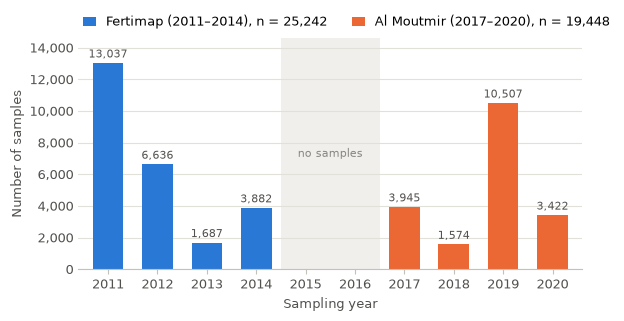

In [88]:
counts = samples.groupby(["year", "project"]).size().rename("n").reset_index()
print(counts.pivot(index="year", columns="project", values="n").fillna(0).astype(int).to_string())

years = np.arange(counts["year"].min(), counts["year"].max() + 1)
fig, ax = plt.subplots(figsize=(6.5, 3.0))

for project, color in PROJECT_COLORS.items():
    sub = counts[counts["project"] == project]
    bars = ax.bar(sub["year"], sub["n"], width=0.62, color=color, label=PROJECT_LABELS[project])
    ax.bar_label(bars, labels=[f"{v:,}" for v in sub["n"]], padding=2, fontsize=8, color=INK_2)

# Shade each run of consecutive years that has no samples.
ymax = counts["n"].max() * 1.12
missing = np.setdiff1d(years, counts["year"])
for run in np.split(missing, np.where(np.diff(missing) != 1)[0] + 1):
    if run.size:
        ax.axvspan(run[0] - 0.5, run[-1] + 0.5, color=EMPTY_BAND, lw=0, zorder=0)
        ax.text(run.mean(), ymax / 2, "no samples", ha="center", va="center", fontsize=8, color=MUTED)

ax.set_xticks(years)
ax.set_xlim(years[0] - 0.6, years[-1] + 0.6)
ax.set_ylim(0, ymax)
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.set_xlabel("Sampling year")
ax.set_ylabel("Number of samples")
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.02), ncol=2, handlelength=1.0, borderaxespad=0)

save(fig, "fig1_samples_per_year")
plt.show()

## Figure 2 — Spatial distribution of soil samples

Al Moutmir samples, the study focus, are drawn on top at full strength; Fertimap
sits underneath as a faint context layer. The map is drawn in Web Mercator,
where meridians and parallels are straight lines, so the degree ticks sit exactly
on them and north is straight up everywhere.

Fertimap is rendered two ways to choose between:
- `points`: every sample as a small pale dot.
- `area`: the ground Fertimap sampled — everything within 1 km of a sample (half its
  ~1 km grid spacing), with gaps narrower than 4 km closed so the outline stays clean.

Every basemap layer is open data, downloaded once into `basemap_cache/`:
- Relief: a hillshade computed here from the Terrain Tiles elevation dataset
  (AWS Open Data registry; SRTM, GMTED2010 and ETOPO1 over Morocco, all public domain).
- Borders: Natural Earth 1:10m (public domain), Morocco point-of-view edition.

In [89]:
CACHE_DIR = Path("basemap_cache")
CACHE_DIR.mkdir(exist_ok=True)
R_EARTH = 6378137.0  # Web Mercator sphere radius, metres
TERRAIN_TILES = "https://s3.amazonaws.com/elevation-tiles-prod/terrarium/{z}/{x}/{y}.png"
NATURAL_EARTH_MAR = "https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_countries_mar.zip"
# Equal-area and centred on Morocco, so buffer distances and areas are true on the ground.
MOROCCO_LAEA = "+proj=laea +lat_0=32 +lon_0=-6 +units=m"


def to_mercator(lon, lat):
    return np.radians(lon) * R_EARTH, np.arcsinh(np.tan(np.radians(lat))) * R_EARTH


def cached_download(url, path):
    if not path.exists():
        response = requests.get(url, timeout=60, headers={"User-Agent": "yg-eo-soilnet paper figures"})
        response.raise_for_status()
        path.write_bytes(response.content)
    return path


def elevation_mosaic(west, south, east, north, zoom):
    """Stitch the Terrain Tiles covering a lon/lat box; returns elevation in metres and its extent in metres."""
    n = 2**zoom
    tile_x = lambda lon: int((lon + 180) / 360 * n)
    tile_y = lambda lat: int((1 - np.arcsinh(np.tan(np.radians(lat))) / np.pi) / 2 * n)
    xs = range(tile_x(west), tile_x(east) + 1)
    ys = range(tile_y(north), tile_y(south) + 1)
    rgb = np.vstack([
        np.hstack([
            np.asarray(Image.open(cached_download(TERRAIN_TILES.format(z=zoom, x=x, y=y),
                                                  CACHE_DIR / f"terrarium_{zoom}_{x}_{y}.png")).convert("RGB"))
            for x in xs
        ])
        for y in ys
    ]).astype(float)
    elevation = rgb[..., 0] * 256 + rgb[..., 1] + rgb[..., 2] / 256 - 32768  # Terrarium encoding
    size, origin = 2 * np.pi * R_EARTH / n, np.pi * R_EARTH
    extent = (-origin + xs[0] * size, -origin + (xs[-1] + 1) * size,
              origin - (ys[-1] + 1) * size, origin - ys[0] * size)
    return elevation, extent


def hillshade(elevation, extent, azimuth=315, altitude=45, exaggeration=3):
    """Lambertian shading lit from the north-west, scaled so flat ground is 1."""
    x_min, x_max, _, y_max = extent
    cell = (x_max - x_min) / elevation.shape[1]  # Web Mercator metres per pixel
    # A Mercator pixel covers cell / cosh(y / R) metres of ground, so each row gets its own spacing.
    row_y = y_max - (np.arange(elevation.shape[0]) + 0.5) * cell
    ground = (cell / np.cosh(row_y / R_EARTH))[:, None]
    d_rows, d_cols = np.gradient(elevation * exaggeration)
    dz_east, dz_north = d_cols / ground, -d_rows / ground  # rows run southwards
    az, alt = np.radians(azimuth), np.radians(altitude)
    light = np.array([np.sin(az) * np.cos(alt), np.cos(az) * np.cos(alt), np.sin(alt)])
    shade = (light[2] - dz_east * light[0] - dz_north * light[1]) / np.sqrt(dz_east**2 + dz_north**2 + 1)
    return np.clip(shade, 0, None) / light[2]


def sampled_area(lon, lat, radius_km, closing_km):
    """Ground within radius_km of a sample, with gaps narrower than 2 * closing_km filled in (equal-area CRS)."""
    points = gpd.GeoSeries(gpd.points_from_xy(lon, lat), crs="EPSG:4326").to_crs(MOROCCO_LAEA)
    grown = points.buffer((radius_km + closing_km) * 1000, resolution=4).union_all()
    return gpd.GeoSeries([grown.buffer(-closing_km * 1000)], crs=MOROCCO_LAEA)


def add_degree_ticks(ax, lons, lats):
    ax.set_xticks(to_mercator(np.asarray(lons), 0)[0], [f"{abs(v)}°{'W' if v < 0 else 'E'}" for v in lons])
    ax.set_yticks(to_mercator(0, np.asarray(lats))[1], [f"{v}°N" for v in lats])
    ax.tick_params(which="both", direction="out", length=3, color=INK_2, labelsize=8,
                   top=True, right=True, labeltop=False, labelright=False)


def add_scale_bar(ax, lon, lat, marks_km=(0, 50, 100, 200), height_km=7):
    """Alternating black/white bar starting at (lon, lat), true to scale at that latitude."""
    x0, y0 = to_mercator(lon, lat)
    stretch = 1000 / np.cos(np.radians(lat))  # Web Mercator metres per ground kilometre here
    height = height_km * stretch
    for i, (a, b) in enumerate(zip(marks_km[:-1], marks_km[1:])):
        ax.add_patch(Rectangle((x0 + a * stretch, y0), (b - a) * stretch, height, lw=0.6, zorder=6,
                               facecolor=INK if i % 2 == 0 else "white", edgecolor=INK))
    for km in marks_km:
        ax.text(x0 + km * stretch, y0 - height * 0.6, f"{km}", ha="center", va="top", fontsize=7, color=INK, zorder=6)
    ax.text(x0 + marks_km[-1] * stretch + height, y0 + height / 2, "km", va="center", fontsize=7, color=INK, zorder=6)


def add_north_arrow(ax, x=0.94, y=0.84, size=0.07):
    """Half-filled arrow in axes coordinates; valid because north is straight up in Web Mercator."""
    tip, base = (x, y + size), y + size * 0.3
    for side, fill in ((-1, INK), (1, "white")):
        ax.add_patch(Polygon([tip, (x + side * size * 0.32, y), (x, base)], closed=True, lw=0.6,
                             facecolor=fill, edgecolor=INK, transform=ax.transAxes, zorder=6))
    ax.text(x, y + size + 0.01, "N", ha="center", va="bottom", fontsize=10, fontweight="bold",
            color=INK, transform=ax.transAxes, zorder=6)

Fertimap sampled area: 54,774 km²


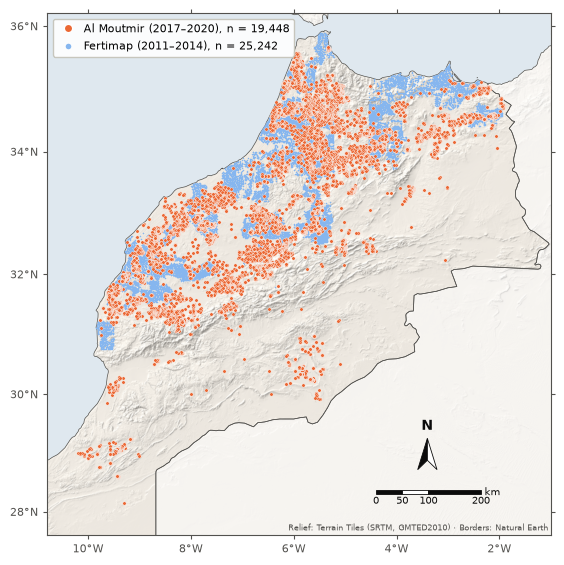

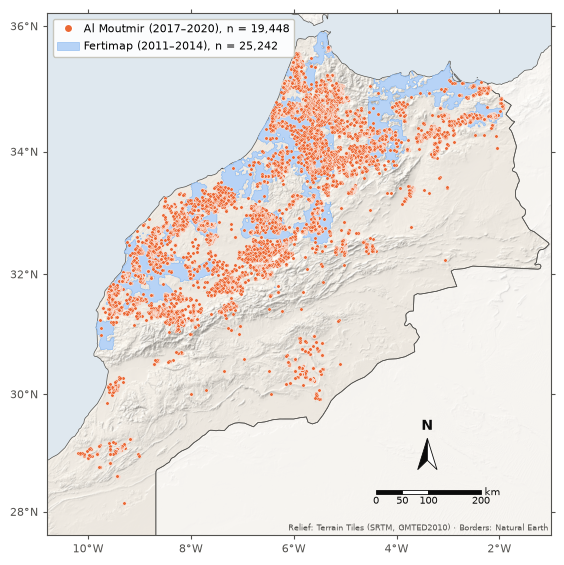

In [90]:
WEST, SOUTH, EAST, NORTH = -10.8, 27.6, -1.0, 36.2  # map bounds, degrees
x_min, y_min = to_mercator(WEST, SOUTH)
x_max, y_max = to_mercator(EAST, NORTH)

# Clip in lon/lat first: Antarctica has no finite Web Mercator coordinates.
countries = gpd.read_file(cached_download(NATURAL_EARTH_MAR, CACHE_DIR / "ne_10m_admin_0_countries_mar.zip"))
countries = countries.clip((WEST - 1, SOUTH - 1, EAST + 1, NORTH + 1)).to_crs("EPSG:3857")
is_morocco = countries["ADM0_A3"] == "MAR"
view = box(x_min, y_min, x_max, y_max)
ocean = gpd.GeoSeries([view], crs="EPSG:3857").difference(countries.union_all())

# Warm light-grey land, darkened on slopes facing away from the light and lifted on those facing it.
LAND = np.array([0.93, 0.91, 0.88])
elevation, relief_extent = elevation_mosaic(WEST, SOUTH, EAST, NORTH, zoom=8)
relief = np.clip(LAND * (0.6 + 0.4 * hillshade(elevation, relief_extent)[..., None]), 0, 1)

xs, ys = to_mercator(samples["lon"].to_numpy(), samples["lat"].to_numpy())
fertimap = samples["project"].eq("Fertimap").to_numpy()
# Kept in the equal-area CRS too: Figure 4 intersects it with Al Moutmir's area.
fertimap_area_laea = sampled_area(samples.loc[fertimap, "lon"], samples.loc[fertimap, "lat"], radius_km=1, closing_km=2)
print(f"Fertimap sampled area: {fertimap_area_laea.area.sum() / 1e6:,.0f} km²")
fertimap_area = fertimap_area_laea.to_crs("EPSG:3857")


def draw_basemap(ax):
    """Relief, sea, veiled neighbours and borders: the ground every map in this notebook sits on."""
    ax.imshow(relief, extent=relief_extent, interpolation="bilinear", zorder=0)
    ocean.plot(ax=ax, color="#dfe8ef", lw=0, zorder=1)
    countries[~is_morocco].plot(ax=ax, color="white", alpha=0.55, lw=0, zorder=1)  # veil the neighbours
    countries.boundary.plot(ax=ax, color=INK_2, lw=0.5, zorder=2)


def finish_map(ax, bounds, lons, lats, scale_bar_at, north_arrow_at):
    """Frame, degree ticks, scale bar, north arrow and credit, then zoom to `bounds` (west, south, east, north)."""
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(INK_2)
        spine.set_linewidth(0.8)
    add_degree_ticks(ax, lons=lons, lats=lats)
    add_scale_bar(ax, *scale_bar_at)
    add_north_arrow(ax, *north_arrow_at)
    ax.text(0.995, 0.005, "Relief: Terrain Tiles (SRTM, GMTED2010) · Borders: Natural Earth",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=5.5, color=INK_2, zorder=6)
    west, south, east, north = bounds
    left, bottom = to_mercator(west, south)
    right, top = to_mercator(east, north)
    ax.set_xlim(left, right)
    ax.set_ylim(bottom, top)
    ax.set_aspect("equal")


def draw_sample_map(fertimap_style):
    """Figure 2, with Fertimap drawn either as individual `points` or as the `area` it sampled."""
    fig, ax = plt.subplots(figsize=(6.5, 6.8))
    draw_basemap(ax)

    # Fertimap in pale opaque blues, so dense clusters cannot stack up into a saturated patch.
    if fertimap_style == "points":
        ax.scatter(xs[fertimap], ys[fertimap], s=1.2, color=FERTIMAP_TINT, lw=0, zorder=3, rasterized=True)
        fertimap_handle = Line2D([], [], ls="", marker="o", markersize=4, markerfacecolor=FERTIMAP_TINT,
                                 markeredgecolor="none", label=PROJECT_LABELS["Fertimap"])
    else:
        fertimap_area.plot(ax=ax, facecolor=FERTIMAP_AREA_FILL, edgecolor=FERTIMAP_TINT, lw=0.4, zorder=3)
        # Same label as the points style: a wider legend would cover the Tangier peninsula.
        fertimap_handle = Patch(facecolor=FERTIMAP_AREA_FILL, edgecolor=FERTIMAP_TINT, lw=0.4,
                                label=PROJECT_LABELS["Fertimap"])

    # Al Moutmir on top, ringed in white so each point reads.
    ax.scatter(xs[~fertimap], ys[~fertimap], s=6, color=PROJECT_COLORS["Al Moutmir"], edgecolor="white",
               lw=0.25, zorder=4, rasterized=True)

    ax.legend(
        handles=[
            Line2D([], [], ls="", marker="o", markersize=6, markerfacecolor=PROJECT_COLORS["Al Moutmir"],
                   markeredgecolor="white", label=PROJECT_LABELS["Al Moutmir"]),
            fertimap_handle,
        ],
        loc="upper left", frameon=True, framealpha=0.9, edgecolor=BASELINE, fontsize=8, handletextpad=0.4,
    )
    # Scale bar and north arrow share the empty lower-right corner, the arrow centred over the bar.
    finish_map(ax, (WEST, SOUTH, EAST, NORTH), lons=[-10, -8, -6, -4, -2], lats=[28, 30, 32, 34, 36],
               scale_bar_at=(-4.4, 28.3), north_arrow_at=(0.755, 0.125, 0.06))
    return fig


# Both candidate styles, one after the other, to choose between.
for style in ("points", "area"):
    fig = draw_sample_map(style)
    save(fig, f"fig2_sample_locations_{style}")
    plt.show()

## Figure 3 — Distribution of key soil properties in the two datasets

Organic matter, pH, Olsen phosphorus and exchangeable potassium, Al Moutmir against
Fertimap. Both datasets share the same bins in each panel, and each histogram shows
the share of *its own* samples per bin, so the two compare despite their different
sizes. Al Moutmir, the study focus, is the solid fill; Fertimap sits behind it as a pale
fill with an outline drawn on top, so its shape stays readable where the two overlap.

Phosphorus is right-skewed over three orders of magnitude, so its panel uses a log axis
(Fertimap's zero readings cannot sit on it). Each panel has a fixed x-range; the cell
prints the share of each dataset falling outside it, for the caption.

Lab values are reported rounded (organic matter to 1 g kg⁻¹, P and K to whole mg kg⁻¹), so each
reading is spread evenly over the rounding interval it stands for before binning; otherwise
bins that happen to catch one extra rounded value stand out as spikes. Spikes that remain are
in the data: Fertimap reports pH 8.1 for 7.0 % of its samples, against ~1.7 % at 8.0 and 8.2.

Share of samples outside each panel's x-range (%):
                  Fertimap  Al Moutmir
organic_matter        0.11        0.04
ph                    1.50        0.01
olsen_p2o5            1.01        0.00
exchangeable_k2o      0.00        0.00


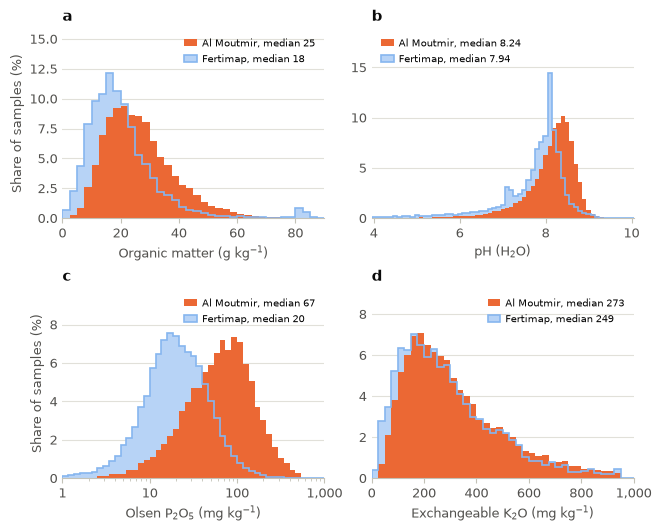

In [91]:
# One entry per property; `name` is its file-name slug when drawn as a figure of its own.
# pH edges sit between tenths because a third of pH readings are reported to one decimal.
PROPERTY_PANELS = [
    dict(name="organic_matter", column="organic_matter_g_kg", label="Organic matter (g kg$^{-1}$)",
         bins=np.arange(0, 90.01, 2.5), log_x=False, median_format="{:.0f}", legend_corner="upper right"),
    dict(name="ph", column="ph_water", label="pH (H$_2$O)",
         bins=np.arange(3.95, 10.06, 0.1), log_x=False, median_format="{:.2f}", legend_corner="upper left"),
    dict(name="olsen_p2o5", column="p2o5_ehangable_olsen_ppm", label="Olsen P$_2$O$_5$ (mg kg$^{-1}$)",
         bins=np.geomspace(1, 1000, 46), log_x=True, median_format="{:.0f}", legend_corner="upper right"),
    dict(name="exchangeable_k2o", column="exchangeable_k2o_ppm", label="Exchangeable K$_2$O (mg kg$^{-1}$)",
         bins=np.arange(0, 1000.1, 25), log_x=False, median_format="{:.0f}", legend_corner="upper right"),
]


def binned_share(values, bins):
    """Percent of readings per bin, each reading spread evenly over the rounding interval it stands for.

    Lab values are reported rounded (pH to 0.1, P and K to whole mg kg⁻¹, ...). Binned as points, bins
    that happen to catch one more rounded value than their neighbours stand out and the histogram
    zigzags; spreading each reading over ±half its reporting step removes that artefact.
    """
    step = next((s for s in (1, 0.1, 0.01) if np.isclose(values / s, np.round(values / s)).mean() >= 0.99), 0.001)
    below_edge = np.clip((bins[:, None] - values.to_numpy()[None, :]) / step + 0.5, 0, 1).mean(axis=1)
    return 100 * np.diff(below_edge)


def draw_property_histogram(ax, panel):
    """One property, Al Moutmir against Fertimap; returns the share of each dataset outside the x-range (%)."""
    bins, handles, peak, outside = panel["bins"], {}, 0, {}
    for project in ("Fertimap", "Al Moutmir"):
        values = samples.loc[samples["project"].eq(project), panel["column"]].dropna()
        share = binned_share(values, bins)
        peak = max(peak, share.max())
        outside[project] = 100 * (~values.between(bins[0], bins[-1])).mean()
        median = panel["median_format"].format(values.median())
        if project == "Fertimap":
            ax.stairs(share, bins, fill=True, color=FERTIMAP_AREA_FILL, lw=0, zorder=1)
            ax.stairs(share, bins, color=FERTIMAP_TINT, lw=1.2, zorder=3)
            handles[project] = Patch(facecolor=FERTIMAP_AREA_FILL, edgecolor=FERTIMAP_TINT, lw=1.2,
                                     label=f"Fertimap, median {median}")
        else:
            ax.stairs(share, bins, fill=True, color=PROJECT_COLORS[project], lw=0, zorder=2)
            handles[project] = Patch(facecolor=PROJECT_COLORS[project], label=f"Al Moutmir, median {median}")

    if panel["log_x"]:
        ax.set_xscale("log")
        ax.set_xticks([1, 10, 100, 1000], ["1", "10", "100", "1,000"])
    else:
        ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,g}"))  # "1,000", as on the log axis
    ax.set_xlim(bins[0], bins[-1])
    ax.set_ylim(0, peak * 1.3)  # headroom so the legend sits clear of the bars
    ax.set_xlabel(panel["label"])
    ax.legend(handles=[handles["Al Moutmir"], handles["Fertimap"]], loc=panel["legend_corner"], fontsize=7.5,
              handlelength=1.2, handletextpad=0.5)
    return outside


fig, axes = plt.subplots(2, 2, figsize=(6.5, 5.2), layout="constrained")
outside = {}
for ax, letter, panel in zip(axes.flat, "abcd", PROPERTY_PANELS):
    outside[panel["name"]] = draw_property_histogram(ax, panel)
    ax.set_title(letter, loc="left", fontweight="bold", color=INK)
for ax in axes[:, 0]:
    ax.set_ylabel("Share of samples (%)")

print("Share of samples outside each panel's x-range (%):")
print(pd.DataFrame(outside).T.round(2).to_string())

save(fig, "fig3_property_distributions")
plt.show()

## Figure 3, one figure per property

The same four histograms as Figure 3, each as a single-column figure of its own
(`figures/fig3_<property>.pdf/png`), for layouts that place them separately. Both
versions are drawn by `draw_property_histogram`, so they cannot drift apart.

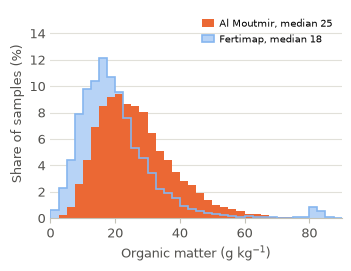

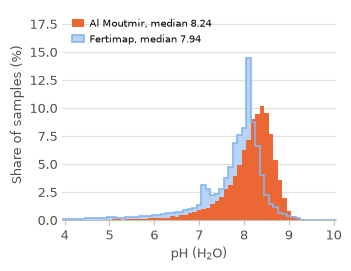

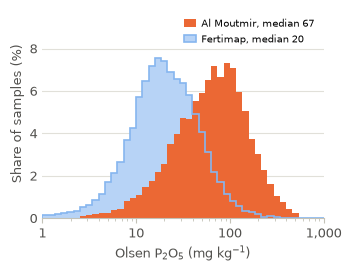

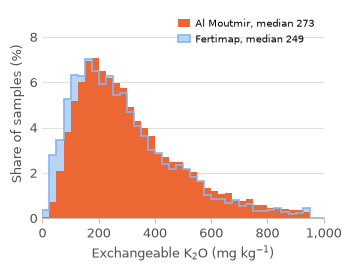

In [92]:
for panel in PROPERTY_PANELS:
    fig, ax = plt.subplots(figsize=(3.4, 2.6), layout="constrained")
    draw_property_histogram(ax, panel)
    ax.set_ylabel("Share of samples (%)")
    save(fig, f"fig3_{panel['name']}")
    plt.show()

## Figure 4 — Organic matter difference, Al Moutmir − Fertimap

Where the two campaigns overlap, how does organic matter at Al Moutmir sites compare with what
Fertimap measured around them? The two never sampled the same spots (Fertimap on a regular ~1 km
grid, Al Moutmir in farm fields), so Fertimap is first estimated at every Al Moutmir sample from
its own nearby samples:

- **Overlap**: ground within 1 km of samples of *both* campaigns (the Figure 2 sampled-area
  definition, applied to each and intersected). Only Al Moutmir samples inside it are compared.
- **Fertimap estimate**: inverse-distance-weighted mean (power 2) of the Fertimap samples within
  2 km, where there are at least 3; distances are floored at 100 m so that a sample sitting on
  the Al Moutmir site does not take all the weight.
- **Difference**: d = Al Moutmir − Fertimap estimate, in g kg⁻¹; orange where Al Moutmir is higher,
  blue where Fertimap is.

Read the regional pattern, not single points: samples a few hundred metres apart already differ
by a median 6 g kg⁻¹ (Al Moutmir) and 4 g kg⁻¹ (Fertimap), about the size of the difference itself.
The difference also mixes change over time (2011–14 → 2017–20), the choice of farms and any lab or
method differences.

**Flagged, kept in:** the dark-blue cluster around Oued Zem–Boujad (≈6.5°W, 32.8°N) comes from a
block of Fertimap readings at 80–86 g kg⁻¹ (376 samples, 1.5 % of Fertimap, nearly all in that
area), far above what the rest of Fertimap (~29 g kg⁻¹) and Al Moutmir (~37 g kg⁻¹) show there. It
looks like a data problem in the Fertimap source; the estimation cell prints the median difference
with and without that area, so the caption can state its effect.

In [93]:
def idw_at(targets_xy, source_xy, source_values, radius_m, min_neighbours, power=2, floor_m=100):
    """Inverse-distance-weighted mean of the source values within radius_m of each target; NaN below min_neighbours."""
    estimates = np.full(len(targets_xy), np.nan)
    for i, neighbours in enumerate(cKDTree(source_xy).query_ball_point(targets_xy, radius_m)):
        if len(neighbours) >= min_neighbours:
            distance = np.maximum(np.linalg.norm(source_xy[neighbours] - targets_xy[i], axis=1), floor_m)
            weights = distance ** -power
            estimates[i] = np.sum(weights * source_values[neighbours]) / weights.sum()
    return estimates


laea = gpd.GeoSeries(gpd.points_from_xy(samples["lon"], samples["lat"]), crs="EPSG:4326").to_crs(MOROCCO_LAEA)
samples_xy = np.column_stack([laea.x, laea.y])
organic_matter = samples["organic_matter_g_kg"].to_numpy()
al_moutmir = ~fertimap

al_moutmir_area = sampled_area(samples.loc[al_moutmir, "lon"], samples.loc[al_moutmir, "lat"], radius_km=1, closing_km=2)
overlap = al_moutmir_area.intersection(fertimap_area_laea)
prepare(overlap.iloc[0])
compared = al_moutmir & contains_xy(overlap.iloc[0], samples_xy[:, 0], samples_xy[:, 1])


def om_difference(radius_m):
    """Al Moutmir organic matter minus the Fertimap estimate at the same site, for every compared sample."""
    fertimap_estimate = idw_at(samples_xy[compared], samples_xy[fertimap], organic_matter[fertimap],
                               radius_m, min_neighbours=3)
    return organic_matter[compared] - fertimap_estimate


# Radius sensitivity for the methods text; the map uses 2 km.
differences = {radius_km: om_difference(radius_km * 1000) for radius_km in (1, 2, 3)}
difference = differences[2]
paired = np.isfinite(difference)
q25, q50, q75 = np.percentile(difference[paired], [25, 50, 75])
print(f"Overlap: {overlap.area.sum() / 1e6:,.0f} km²; {compared.sum():,} Al Moutmir samples inside it, "
      f"{paired.sum():,} with ≥ 3 Fertimap samples within 2 km")
print(f"Al Moutmir − Fertimap: median {q50:+.1f} g kg⁻¹, IQR {q25:+.1f} to {q75:+.1f}")
print(pd.DataFrame(
    {"pairs": [np.isfinite(d).sum() for d in differences.values()],
     "median (g kg⁻¹)": [np.nanmedian(d).round(1) for d in differences.values()]},
    index=[f"{radius_km} km" for radius_km in differences],
).to_string())

# Flagged, not removed: Fertimap's block of 80–86 g kg⁻¹ readings around Oued Zem–Boujad (see the notes).
block_area = (samples["lon"].between(-6.9, -6.1) & samples["lat"].between(32.6, 33.05)).to_numpy()[compared][paired]
print(f"Oued Zem–Boujad box (6.1–6.9°W, 32.6–33.05°N): {block_area.sum():,} of {paired.sum():,} pairs; "
      f"median difference without them {np.median(difference[paired][~block_area]):+.1f} g kg⁻¹ (with them {q50:+.1f})")

Overlap: 10,611 km²; 8,100 Al Moutmir samples inside it, 7,345 with ≥ 3 Fertimap samples within 2 km
Al Moutmir − Fertimap: median +5.0 g kg⁻¹, IQR -1.4 to +12.6
      pairs  median (g kg⁻¹)
1 km   1992              5.1
2 km   7345              5.0
3 km   8055              5.0
Oued Zem–Boujad box (6.1–6.9°W, 32.6–33.05°N): 448 of 7,345 pairs; median difference without them +5.5 g kg⁻¹ (with them +5.0)


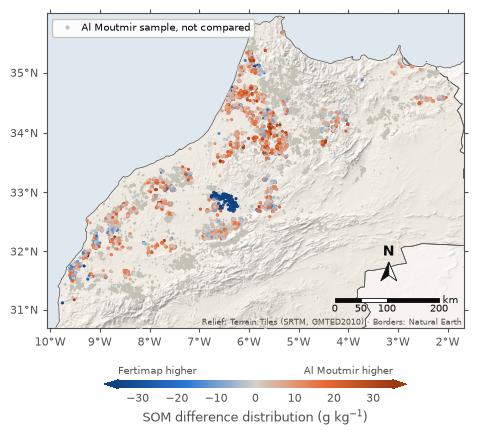

In [94]:
# Fertimap blue (Fertimap higher) through a neutral grey to Al Moutmir orange (Al Moutmir higher).
OM_DIFFERENCE_CMAP = LinearSegmentedColormap.from_list(
    "fertimap_to_al_moutmir", ["#104281", PROJECT_COLORS["Fertimap"], "#d3d1c9", PROJECT_COLORS["Al Moutmir"], "#9a3b12"]
)
limit = np.ceil(np.percentile(np.abs(difference[paired]), 95) / 5) * 5  # symmetric, so 0 sits at the grey

# Zoom to the overlap, with a margin so the points at its edge are not cut.
o_west, o_south, o_east, o_north = overlap.to_crs("EPSG:4326").total_bounds
bounds = (o_west - 0.3, o_south - 0.3, o_east + 0.3, o_north + 0.3)

site = np.flatnonzero(compared)[paired]
order = np.random.default_rng(0).permutation(len(site))  # no value class always drawn on top

fig, ax = plt.subplots(figsize=(6.5, 5.6))
draw_basemap(ax)
# Al Moutmir samples left out of the comparison, in grey, so it is clear where one was possible.
not_compared = al_moutmir.copy()
not_compared[site] = False
ax.scatter(xs[not_compared], ys[not_compared], s=1.5, color=BASELINE, lw=0, zorder=3, rasterized=True)
points = ax.scatter(xs[site][order], ys[site][order], c=difference[paired][order], cmap=OM_DIFFERENCE_CMAP,
                    vmin=-limit, vmax=limit, s=5, lw=0, zorder=4, rasterized=True)
ax.legend(handles=[Line2D([], [], ls="", marker="o", markersize=3, markerfacecolor=BASELINE,
                          markeredgecolor="none", label="Al Moutmir sample, not compared")],
          loc="upper left", frameon=True, framealpha=0.9, edgecolor=BASELINE, fontsize=7.5, handletextpad=0.4)

colorbar = fig.colorbar(points, ax=ax, orientation="horizontal", extend="both", shrink=0.6, pad=0.12, aspect=35)
colorbar.set_label("SOM difference distribution (g kg$^{-1}$)")
colorbar.outline.set_visible(False)
colorbar.ax.tick_params(length=0, labelsize=8)
for x, text, align in ((0, "Fertimap higher", "left"), (1, "Al Moutmir higher", "right")):
    colorbar.ax.text(x, 1.4, text, transform=colorbar.ax.transAxes, ha=align, va="bottom", fontsize=7.5, color=INK_2)

finish_map(ax, bounds,
           lons=list(range(int(np.ceil(bounds[0])), int(np.floor(bounds[2])) + 1)),
           lats=list(range(int(np.ceil(bounds[1])), int(np.floor(bounds[3])) + 1)),
           scale_bar_at=(bounds[2] - 2.6, bounds[1] + 0.45), north_arrow_at=(0.82, 0.15, 0.06))

save(fig, "fig4_om_difference")
plt.show()

## Figure 5 — How soil organic matter relates to the other soil properties, per dataset

Spearman rank correlation (ρ) between soil organic matter (SOM) and every other measured soil
property, computed separately for each dataset over the samples that have both values. Rank
correlation is used because most properties are strongly skewed (P, K, EC, micronutrients) and
it is not driven by a handful of extreme readings. Location, date, depth and ids are not soil
properties and are left out. Properties are sorted by their Al Moutmir ρ; the Fertimap figure keeps
the same order and the same x-axis, so the two read side by side.

Fertimap measured only SOM, pH, P and K in quantity (EC for 60 samples, everything else for at most
4), so its figure has three bars: a property needs at least 100 paired samples to be shown, and the
cell prints what was left out. With thousands of pairs even |ρ| ≈ 0.05 is statistically
significant, so read the size of ρ rather than its significance. A few pairs are linked by
construction: the C/N ratio contains organic carbon, total silt includes fine and coarse silt, sand,
silt and clay are fractions of one whole, and Na₂O and exchangeable Na both measure sodium.

                              pairs                 rho         
project                  Al Moutmir Fertimap Al Moutmir Fertimap
property                                                        
c_e_c_meq_100g                16579        4       0.38      NaN
p2o5_ehangable_olsen_ppm      19448    25223       0.36     0.10
c_n_ratio                     14906        4       0.31      NaN
fine_silt_pct                 16532        4       0.30      NaN
mn_ppm_dtpa                   18248        4       0.27      NaN
cao_ppm                        2526        0       0.27      NaN
caco3_pct_total               17862        4       0.26      NaN
total_silt_pct                16534        4       0.25      NaN
b_ppm_hot_water               14136        4       0.19      NaN
zn_ppm_dtpa                   18246        4       0.18      NaN
exchangeable_k2o_ppm          19320    25232       0.15     0.26
ce_ext1_5_ms_cm               19447       60       0.15      NaN
coarse_element_pct       

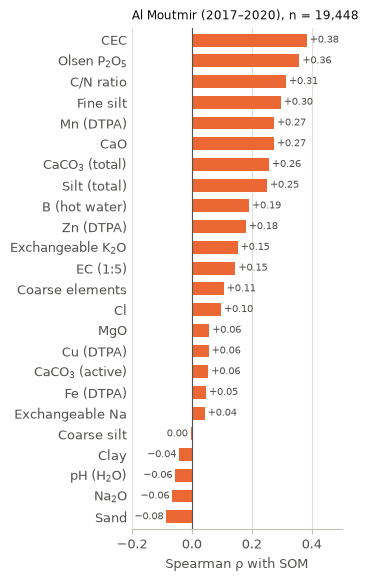

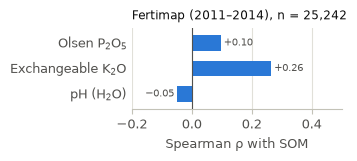

In [95]:
# Display names of the soil properties; every other column (location, date, depth, id) is not one.
PROPERTY_NAMES = {
    "sand_pct": "Sand", "total_silt_pct": "Silt (total)", "fine_silt_pct": "Fine silt",
    "coarse_silt_pct": "Coarse silt", "clay_pct": "Clay", "coarse_element_pct": "Coarse elements",
    "ph_water": "pH (H$_2$O)", "caco3_pct_total": "CaCO$_3$ (total)", "caco3_active_pct": "CaCO$_3$ (active)",
    "c_e_c_meq_100g": "CEC", "ce_ext1_5_ms_cm": "EC (1:5)", "na2o_ppm": "Na$_2$O", "cl_ppm": "Cl",
    "na_meq_100g": "Exchangeable Na", "c_n_ratio": "C/N ratio", "exchangeable_k2o_ppm": "Exchangeable K$_2$O",
    "p2o5_ehangable_olsen_ppm": "Olsen P$_2$O$_5$", "mgo_ppm": "MgO", "cao_ppm": "CaO",
    "iron_ppm_dtpa": "Fe (DTPA)", "mn_ppm_dtpa": "Mn (DTPA)", "cu_ppm_dtpa": "Cu (DTPA)",
    "zn_ppm_dtpa": "Zn (DTPA)", "b_ppm_hot_water": "B (hot water)",
}
MIN_PAIRS = 100  # below this many paired samples a correlation is too unstable to show

rows = []
for project, group in samples.groupby("project"):
    for column in PROPERTY_NAMES:
        both = group[[column, "organic_matter_g_kg"]].dropna()
        rho = both[column].corr(both["organic_matter_g_kg"], method="spearman") if len(both) >= MIN_PAIRS else np.nan
        rows.append({"property": column, "project": project, "pairs": len(both), "rho": rho})
correlations = pd.DataFrame(rows).pivot(index="property", columns="project")
order = correlations["rho"]["Al Moutmir"].sort_values().index  # ascending, so the strongest ends up on top

print(correlations.reindex(order[::-1]).round(2).to_string())
left_out = correlations.index[correlations["rho"]["Fertimap"].isna()]
print(f"Fertimap: {len(left_out)} properties with fewer than {MIN_PAIRS} paired samples left out")

# One x-range for both figures, with room for the value labels at the bar ends.
all_rho = correlations["rho"].stack()
x_range = (np.floor((min(all_rho.min(), 0) - 0.08) * 10) / 10, np.ceil((all_rho.max() + 0.1) * 10) / 10)


def draw_om_correlations(project):
    """Horizontal bars of ρ(SOM, property) for one dataset, in the shared property order and x-range."""
    rho = correlations["rho"][project].reindex(order).dropna()
    rows_y = np.arange(len(rho))
    fig, ax = plt.subplots(figsize=(3.4, 0.9 + 0.2 * len(rho)), layout="constrained")
    ax.barh(rows_y, rho, height=0.62, color=PROJECT_COLORS[project], zorder=2)
    for y, value in zip(rows_y, rho):
        label = "0.00" if abs(value) < 0.005 else f"{value:+.2f}".replace("-", "−")  # true minus, like the axis
        ax.text(value + (0.01 if value >= 0 else -0.01), y, label, ha="left" if value >= 0 else "right",
                va="center", fontsize=7, color=INK_2)
    ax.axvline(0, color=INK_2, lw=0.8, zorder=3)
    ax.grid(False)
    ax.grid(True, axis="x")
    ax.set_yticks(rows_y, [PROPERTY_NAMES[column] for column in rho.index])
    ax.tick_params(axis="y", length=0)
    ax.set_xlim(*x_range)
    ax.set_ylim(-0.6, len(rho) - 0.4)
    ax.set_xlabel("Spearman ρ with SOM")
    ax.set_title(PROJECT_LABELS[project], loc="left", fontsize=8.5, color=INK)
    return fig


for project in ("Al Moutmir", "Fertimap"):
    fig = draw_om_correlations(project)
    save(fig, f"fig5_om_correlations_{project.lower().replace(' ', '_')}")
    plt.show()

## Figure 6 — Barest-earth Sentinel-2 spectra by soil organic matter level

Median barest-earth Sentinel-2 surface reflectance for five SOM classes (fixed 10 g kg⁻¹ steps). The
spectra come from the static covariates (`Morocco_Static_Covariates_Processed_V_310826.csv`), joined by
`uuid` to the SOM values of the 6k training sample (`Morocco_soil_targets_uuid_roadsafe_6ksample_V_310826.csv`).
That sample is Al Moutmir topsoil apart from two Fertimap points, which are left out, as are the few spectra
with a band outside the physical 0.01–1 reflectance range (fill values or saturation); the cell prints both
counts.

Panel a shows the median spectrum of each class, with the interquartile range of the lowest and highest
classes as ribbons; panel b subtracts the median spectrum of all samples, which makes differences of one or
two hundredths of reflectance readable. Lines are solid between neighbouring bands and faint across the
865–1612 nm gap, where there is no band.

**Read with the carbonate confound in mind.** Higher-SOM soils in this sample are also the calcareous ones
(median CaCO₃ ≈ 1 % in the < 10 g kg⁻¹ class against ≈ 26 % at ≥ 40 g kg⁻¹), and carbonate brightens soil,
so the high-SOM classes come out slightly *brighter* rather than darker. Band-wise correlations with SOM are
weak (Spearman ρ ≈ +0.06–0.08 in the visible and near infrared, ≈ 0 in the SWIR); the cell prints the class
medians, CaCO₃ per class and the band correlations for the caption.

5,295 samples with both SOM and a barest-earth spectrum; leaving out 2 that are not Al Moutmir and 4 spectra outside 0.01–1 reflectance
              n  median CaCO3 (%)
som_class                        
< 10        147               1.4
10–20      1335               3.8
20–30      1927              12.1
30–40      1149              21.7
≥ 40        731              26.1
              b2     b3     b4     b5     b6     b7     b8    b8a    b11    b12
som_class                                                                      
< 10       0.073  0.112  0.175  0.204  0.227  0.246  0.255  0.265  0.371  0.335
10–20      0.087  0.127  0.185  0.214  0.237  0.254  0.262  0.273  0.374  0.330
20–30      0.088  0.127  0.183  0.211  0.237  0.256  0.262  0.274  0.357  0.309
30–40      0.088  0.130  0.189  0.218  0.243  0.263  0.268  0.282  0.369  0.320
≥ 40       0.091  0.134  0.190  0.224  0.251  0.272  0.276  0.292  0.388  0.337
Spearman ρ with SOM: {'b2': 0.08, 'b3': 0.07, 'b4': 0.06, 'b5': 0.

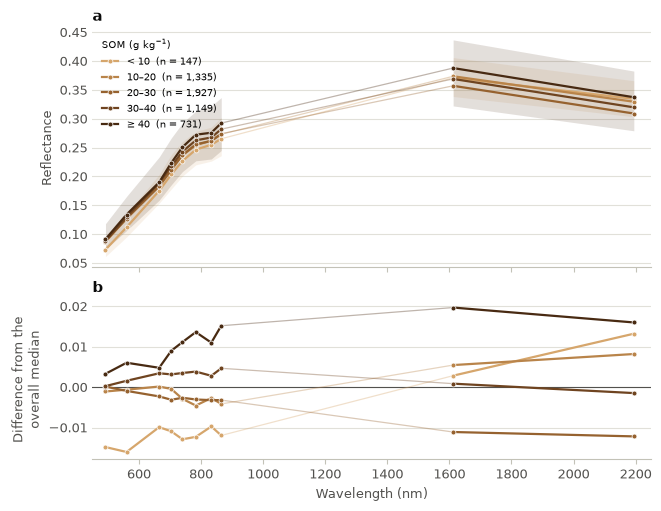

In [96]:
# Barest-earth band columns and their Sentinel-2 centre wavelengths (nm, mean of S2A and S2B).
S2_BAND_CENTRES = {"b2": 492, "b3": 560, "b4": 665, "b5": 704, "b6": 740, "b7": 783, "b8": 833, "b8a": 865,
                   "b11": 1612, "b12": 2194}
band_columns = [f"s2_{band}_barest" for band in S2_BAND_CENTRES]
wavelengths = np.array(list(S2_BAND_CENTRES.values()))
vnir = wavelengths < 1000  # B2–B8A; B11 and B12 are the SWIR bands, 750 nm further on

targets = pd.read_csv(DATASET_CSV.parent / "Morocco_soil_targets_uuid_roadsafe_6ksample_V_310826.csv",
                      usecols=["uuid", "organic_matter_g_kg", "caco3_pct_total"])
covariates = pd.read_csv(DATASET_CSV.parent / "Morocco_Static_Covariates_Processed_V_310826.csv",
                         usecols=["uuid", *band_columns])
spectra = targets.merge(covariates, on="uuid").merge(samples[["uuid", "project"]], on="uuid", how="left")
valid = spectra[band_columns].ge(0.01).all(axis=1) & spectra[band_columns].le(1).all(axis=1)
al_moutmir_sample = spectra["project"].eq("Al Moutmir")
print(f"{len(spectra):,} samples with both SOM and a barest-earth spectrum; leaving out "
      f"{(~al_moutmir_sample).sum()} that are not Al Moutmir and {(~valid).sum()} spectra outside 0.01–1 reflectance")
spectra = spectra[al_moutmir_sample & valid].reset_index(drop=True)

SOM_CLASS_LABELS = ["< 10", "10–20", "20–30", "30–40", "≥ 40"]
spectra["som_class"] = pd.cut(spectra["organic_matter_g_kg"], [-np.inf, 10, 20, 30, 40, np.inf], right=False,
                              labels=SOM_CLASS_LABELS)
by_class = spectra.groupby("som_class", observed=True)
class_median, class_q25, class_q75 = (by_class[band_columns].quantile(q) for q in (0.5, 0.25, 0.75))
overall_median = spectra[band_columns].median()
class_n = by_class.size()

print(pd.DataFrame({"n": class_n, "median CaCO3 (%)": by_class["caco3_pct_total"].median().round(1)}).to_string())
print(class_median.set_axis(list(S2_BAND_CENTRES), axis=1).round(3).to_string())
print("Spearman ρ with SOM:", {band: round(float(spectra[column].corr(spectra["organic_matter_g_kg"], method="spearman")), 2)
                               for band, column in zip(S2_BAND_CENTRES, band_columns)})

# One hue, light tan (low SOM) to dark brown (high SOM); the lightest step still clears ~2:1 on white.
SOM_RAMP = ["#d6a66c", "#b9844a", "#96622f", "#6f4420", "#482a12"]


def draw_spectrum(ax, values, color, label=None):
    """Solid line and markers within the VNIR and within the SWIR, a faint connector across the gap between."""
    for part in (vnir, ~vnir):
        ax.plot(wavelengths[part], values[part], color=color, lw=1.6, marker="o", markersize=3.5,
                markeredgecolor="white", markeredgewidth=0.5, label=label if part is vnir else None, zorder=3)
    gap = [np.flatnonzero(vnir)[-1], np.flatnonzero(~vnir)[0]]
    ax.plot(wavelengths[gap], values[gap], color=color, lw=0.9, alpha=0.35, zorder=2)


fig, (ax_spectra, ax_difference) = plt.subplots(2, 1, figsize=(6.5, 5.0), sharex=True, height_ratios=[3, 2],
                                                layout="constrained")
for label, color in zip(SOM_CLASS_LABELS, SOM_RAMP):
    values = class_median.loc[label].to_numpy()
    draw_spectrum(ax_spectra, values, color, label=f"{label}  (n = {class_n[label]:,})")
    draw_spectrum(ax_difference, values - overall_median.to_numpy(), color)
# Interquartile ribbons for the two extreme classes only: all five would bury the lines.
for label, color in ((SOM_CLASS_LABELS[0], SOM_RAMP[0]), (SOM_CLASS_LABELS[-1], SOM_RAMP[-1])):
    for part in (vnir, ~vnir):
        ax_spectra.fill_between(wavelengths[part], class_q25.loc[label].to_numpy()[part],
                                class_q75.loc[label].to_numpy()[part], color=color, alpha=0.15, lw=0, zorder=1)

ax_spectra.set_ylabel("Reflectance")
ax_spectra.legend(title="SOM (g kg$^{-1}$)", loc="upper left", fontsize=7.5, title_fontsize=7.5,
                  alignment="left", handlelength=1.6)
ax_difference.axhline(0, color=INK_2, lw=0.8, zorder=1)
ax_difference.set_ylabel("Difference from the\noverall median")
ax_difference.set_xlabel("Wavelength (nm)")
ax_difference.set_xlim(450, 2250)
for ax, letter in ((ax_spectra, "a"), (ax_difference, "b")):
    ax.set_title(letter, loc="left", fontweight="bold", color=INK)

save(fig, "fig6_s2_barest_spectra_by_som")
plt.show()

## Figure 7 — Carbonate and barest-earth reflectance, and SOM once carbonate is accounted for

Figure 6 found high-SOM soils slightly *brighter*. This figure brings total CaCO₃ in, on the same Al Moutmir
spectra (the few without a CaCO₃ value are left out; the cell prints the count), with carbonate grouped into
the FAO calcareousness classes: slightly (< 2 %), moderately (2–10 %), strongly (10–25 %) and extremely
(≥ 25 %) calcareous.

- **a** — median spectrum per carbonate class: the most calcareous soils are ~0.04 brighter across the
  spectrum, about twice the largest SOM-class difference in Figure 6.
- **b** — per band, Spearman ρ with CaCO₃, with SOM, and SOM's *partial* ρ with CaCO₃ held constant (the
  ranks of the band and of SOM are each regressed on the CaCO₃ rank, and the residuals correlated). SOM's weak
  positive correlation (+0.06…+0.08) turns negative (−0.03…−0.08) once carbonate is accounted for: the
  darkening expected from organic matter, masked by carbonate.
- **c–f** — within each carbonate class, each SOM class's median spectrum minus that carbonate class's own
  median. In slightly and moderately calcareous soils (< 10 % CaCO₃) the high-SOM classes sit below zero
  (darker), most clearly in the SWIR (about −0.04 for ≥ 40 g kg⁻¹ in the < 2 % class); in strongly
  calcareous soils the SOM classes barely separate, and in extremely calcareous soils the highest-SOM class
  is slightly brighter. A SOM class with fewer than 30 samples in a carbonate class is not drawn.

SOM and CaCO₃ are themselves correlated in this sample (Spearman ρ = 0.37), which is why they confound each
other in Figure 6. The cell prints the carbonate × SOM counts and the correlation table for the caption.

5,261 of 5,289 spectra have a CaCO₃ value
som_class        < 10  10–20  20–30  30–40  ≥ 40   All
carbonate_class                                       
< 2                94    597    441    156    95  1383
2–10               22    232    397    189    90   930
10–25              19    281    618    337   142  1397
≥ 25               11    210    462    464   404  1551
All               146   1320   1918   1146   731  5261
     CaCO3   SOM  SOM | CaCO3
b2    0.31  0.08        -0.04
b3    0.30  0.07        -0.04
b4    0.28  0.06        -0.05
b5    0.27  0.06        -0.04
b6    0.26  0.07        -0.03
b7    0.26  0.07        -0.03
b8    0.27  0.06        -0.04
b8a   0.27  0.08        -0.03
b11   0.20  0.01        -0.07
b12   0.18 -0.00        -0.08
Not drawn (too few samples): ['SOM < 10 in CaCO₃ 2–10 % (n = 22)', 'SOM < 10 in CaCO₃ 10–25 % (n = 19)', 'SOM < 10 in CaCO₃ ≥ 25 % (n = 11)']


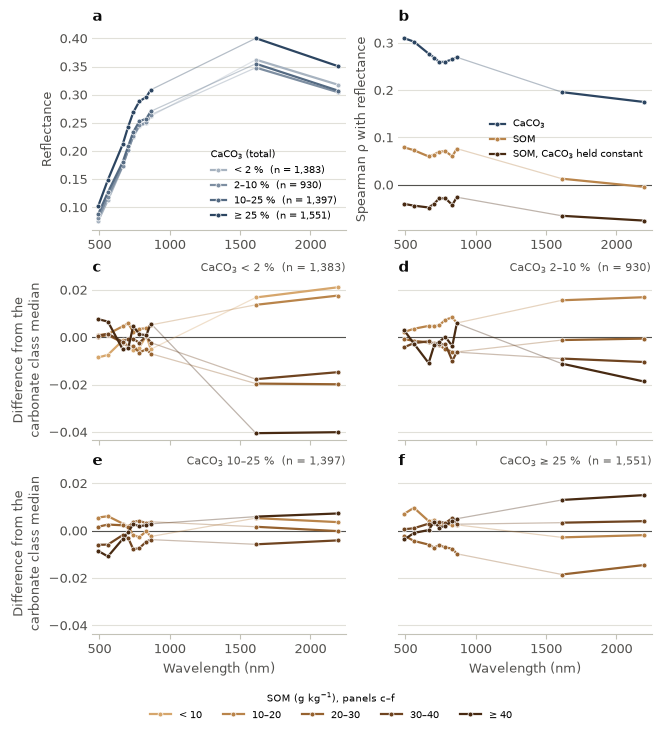

In [97]:
CARBONATE_CLASS_LABELS = ["< 2", "2–10", "10–25", "≥ 25"]  # FAO: slightly / moderately / strongly / extremely calcareous
# One slate hue, light (low CaCO₃) to deep (high); the lightest step still clears ~2:1 on white.
CARBONATE_RAMP = ["#a7b3c0", "#7d8ea1", "#546a82", "#2c4561"]
MIN_CELL = 30  # a SOM class with fewer samples than this in a carbonate class is not drawn there

carbonate = spectra.dropna(subset=["caco3_pct_total"]).copy()
print(f"{len(carbonate):,} of {len(spectra):,} spectra have a CaCO₃ value")
carbonate["carbonate_class"] = pd.cut(carbonate["caco3_pct_total"], [-np.inf, 2, 10, 25, np.inf], right=False,
                                      labels=CARBONATE_CLASS_LABELS)
print(pd.crosstab(carbonate["carbonate_class"], carbonate["som_class"], margins=True).to_string())

# Spearman ρ per band with CaCO₃ and with SOM, and SOM's partial ρ with CaCO₃ held constant.
ranks = carbonate[[*band_columns, "organic_matter_g_kg", "caco3_pct_total"]].rank()


def without_carbonate(column):
    """Ranks of `column` with their linear dependence on the CaCO₃ rank removed."""
    slope, intercept = np.polyfit(ranks["caco3_pct_total"], ranks[column], 1)
    return ranks[column] - (slope * ranks["caco3_pct_total"] + intercept)


som_residual = without_carbonate("organic_matter_g_kg")
correlation_profile = pd.DataFrame({
    "CaCO3": [ranks[column].corr(ranks["caco3_pct_total"]) for column in band_columns],
    "SOM": [ranks[column].corr(ranks["organic_matter_g_kg"]) for column in band_columns],
    "SOM | CaCO3": [without_carbonate(column).corr(som_residual) for column in band_columns],
}, index=list(S2_BAND_CENTRES))
print(correlation_profile.round(2).to_string())
PROFILE_LINES = [("CaCO3", "CaCO$_3$", CARBONATE_RAMP[-1]), ("SOM", "SOM", SOM_RAMP[1]),
                 ("SOM | CaCO3", "SOM, CaCO$_3$ held constant", SOM_RAMP[-1])]

fig = plt.figure(figsize=(6.5, 7.2), layout="constrained")
grid = fig.add_gridspec(3, 2, height_ratios=[1.25, 1, 1])
ax_carbonate, ax_correlation = fig.add_subplot(grid[0, 0]), fig.add_subplot(grid[0, 1])
strata_axes = [fig.add_subplot(grid[1, 0])]
strata_axes += [fig.add_subplot(grid[1 + i // 2, i % 2], sharey=strata_axes[0]) for i in range(1, 4)]

for label, color in zip(CARBONATE_CLASS_LABELS, CARBONATE_RAMP):
    group = carbonate[carbonate["carbonate_class"] == label]
    draw_spectrum(ax_carbonate, group[band_columns].median().to_numpy(), color,
                  label=f"{label} %  (n = {len(group):,})")
ax_carbonate.set_ylabel("Reflectance")
# Legends go where the lines are not: lower right in a, between the CaCO₃ and SOM lines in b.
ax_carbonate.legend(title="CaCO$_3$ (total)", loc="lower right", fontsize=7, title_fontsize=7, alignment="left",
                    handlelength=1.6)

for column, label, color in PROFILE_LINES:
    draw_spectrum(ax_correlation, correlation_profile[column].to_numpy(), color, label=label)
ax_correlation.axhline(0, color=INK_2, lw=0.8, zorder=1)
ax_correlation.set_ylabel("Spearman ρ with reflectance")
ax_correlation.legend(loc="center right", bbox_to_anchor=(1, 0.45), fontsize=7, handlelength=1.6)

left_out = []
for ax, letter, label in zip(strata_axes, "cdef", CARBONATE_CLASS_LABELS):
    stratum = carbonate[carbonate["carbonate_class"] == label]
    stratum_median = stratum[band_columns].median().to_numpy()
    for som_label, color in zip(SOM_CLASS_LABELS, SOM_RAMP):
        cell = stratum[stratum["som_class"] == som_label]
        if len(cell) < MIN_CELL:
            left_out.append(f"SOM {som_label} in CaCO₃ {label} % (n = {len(cell)})")
            continue
        draw_spectrum(ax, cell[band_columns].median().to_numpy() - stratum_median, color)
    ax.axhline(0, color=INK_2, lw=0.8, zorder=1)
    ax.set_title(f"CaCO$_3$ {label} %  (n = {len(stratum):,})", loc="right", fontsize=8, color=INK_2)
print("Not drawn (too few samples):", left_out or "none")

for ax, letter in zip([ax_carbonate, ax_correlation, *strata_axes], "abcdef"):
    ax.set_title(letter, loc="left", fontweight="bold", color=INK)
    ax.set_xlim(450, 2250)
for ax in strata_axes[:2]:
    ax.tick_params(labelbottom=False)
for ax in strata_axes[2:]:
    ax.set_xlabel("Wavelength (nm)")
for ax in strata_axes[1::2]:
    ax.tick_params(labelleft=False)
for ax in strata_axes[::2]:
    ax.set_ylabel("Difference from the\ncarbonate class median")
fig.legend(handles=[Line2D([], [], color=color, lw=1.6, marker="o", markersize=3.5, markeredgecolor="white",
                           markeredgewidth=0.5) for color in SOM_RAMP],
           labels=SOM_CLASS_LABELS, title="SOM (g kg$^{-1}$), panels c–f", loc="outside lower center", ncol=5,
           fontsize=7.5, title_fontsize=7.5)

save(fig, "fig7_carbonate_reflectance")
plt.show()

## Figure 7, panels c–f in actual reflectance

The same comparison as Figure 7 c–f (SOM classes within each FAO carbonate class), drawn in actual
reflectance instead of as differences. Each panel shows the SOM classes' median spectra over that carbonate
class's median spectrum, drawn as a thick grey reference line. All four panels share one reflectance axis, so
carbonate's brightening from panel to panel stays visible next to the SOM spread inside each panel. As in
Figure 7, a SOM class with fewer than 30 samples in a carbonate class is not drawn.

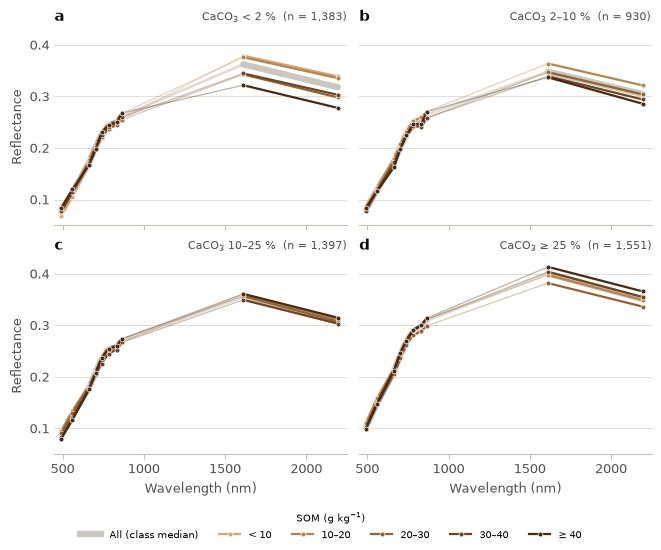

In [98]:
REFERENCE_GREY = "#c9c7bf"

fig, axes = plt.subplots(2, 2, figsize=(6.5, 5.4), sharex=True, sharey=True, layout="constrained")
for ax, letter, label in zip(axes.flat, "abcd", CARBONATE_CLASS_LABELS):
    stratum = carbonate[carbonate["carbonate_class"] == label]
    reference = stratum[band_columns].median().to_numpy()
    # The carbonate class's own median, under the SOM lines, with the same faint bridge across the gap.
    for part in (vnir, ~vnir):
        ax.plot(wavelengths[part], reference[part], color=REFERENCE_GREY, lw=4.5, solid_capstyle="round", zorder=1)
    gap = [np.flatnonzero(vnir)[-1], np.flatnonzero(~vnir)[0]]
    ax.plot(wavelengths[gap], reference[gap], color=REFERENCE_GREY, lw=2, alpha=0.6, zorder=1)
    for som_label, color in zip(SOM_CLASS_LABELS, SOM_RAMP):
        cell = stratum[stratum["som_class"] == som_label]
        if len(cell) >= MIN_CELL:
            draw_spectrum(ax, cell[band_columns].median().to_numpy(), color)
    ax.set_title(letter, loc="left", fontweight="bold", color=INK)
    ax.set_title(f"CaCO$_3$ {label} %  (n = {len(stratum):,})", loc="right", fontsize=8, color=INK_2)
    ax.set_xlim(450, 2250)
for ax in axes[1]:
    ax.set_xlabel("Wavelength (nm)")
for ax in axes[:, 0]:
    ax.set_ylabel("Reflectance")
fig.legend(handles=[Line2D([], [], color=REFERENCE_GREY, lw=4.5),
                    *[Line2D([], [], color=color, lw=1.6, marker="o", markersize=3.5, markeredgecolor="white",
                             markeredgewidth=0.5) for color in SOM_RAMP]],
           labels=["All (class median)", *SOM_CLASS_LABELS], title="SOM (g kg$^{-1}$)", loc="outside lower center",
           ncol=6, fontsize=7.5, title_fontsize=7.5)

save(fig, "fig7_som_spectra_by_carbonate_class")
plt.show()

## Figure 8 — Is SOM's effect on reflectance significant, and does carbonate change it?

Figure 7 suggests that SOM darkens barest-earth reflectance in non-calcareous soils but not in calcareous
ones. This figure tests that, band by band, on the same 5,261 Al Moutmir spectra:

- **a** — Spearman ρ between SOM and reflectance over all samples, raw and with CaCO₃ held constant (as in
  Figure 7b).
- **b** — ρ(SOM, reflectance) within each FAO carbonate class.
- **c** — carbonate's effect on that link: each class's ρ minus the < 2 % class's ρ (an interaction test).

**Significance.** Neighbouring farms are not independent samples, so the intervals come from a spatial block
bootstrap: samples are grouped into 10 km blocks (659 of them), whole blocks are resampled with replacement
1,000 times, and every quantity is recomputed each time; the bars span the 2.5–97.5 % percentiles. Two-sided
bootstrap p-values are Holm-corrected within each panel (20, 40 and 30 tests), and filled markers are
significant at α = 0.05. The bootstrap takes about half a minute.

**Result.**
- Only the SWIR carries a significant SOM signal: in slightly calcareous soils (< 2 % CaCO₃), higher SOM
  means darker B11 and B12 (ρ = −0.27 and −0.30).
- Carbonate significantly changes that link in the SWIR: relative to < 2 % soils, ρ rises by +0.19 (2–10 %,
  B12), +0.23 / +0.27 (10–25 %, B11 / B12) and +0.41 / +0.44 (≥ 25 %, B11 / B12). In extremely calcareous
  soils higher SOM even goes with slightly brighter SWIR (ρ ≈ +0.15, not significant after correction).
- No visible or near-infrared effect survives the spatial bootstrap and the correction, and neither does the
  whole-sample correlation, raw or with CaCO₃ held constant (B12 comes closest: −0.08, 95 % CI −0.13 to −0.01
  before correction).

The cell prints every estimate with its interval, starred where significant, for the caption.

5,261 spectra in 659 blocks of 10 km (median 3 samples per block)
ρ [95 % block-bootstrap CI]; * = significant after Holm correction within each panel (α = 0.05)
                                       b2                    b3                    b4                    b5                    b6                    b7                    b8                   b8a                    b11                    b12
SOM                  +0.08 [+0.01, +0.16]  +0.07 [+0.00, +0.16]  +0.06 [-0.01, +0.13]  +0.06 [-0.00, +0.13]  +0.07 [+0.00, +0.14]  +0.07 [+0.00, +0.14]  +0.06 [-0.00, +0.13]  +0.08 [+0.01, +0.14]   +0.01 [-0.06, +0.09]   -0.00 [-0.07, +0.07]
SOM | CaCO3          -0.04 [-0.10, +0.02]  -0.04 [-0.10, +0.02]  -0.05 [-0.10, +0.01]  -0.04 [-0.09, +0.01]  -0.03 [-0.08, +0.03]  -0.03 [-0.08, +0.03]  -0.04 [-0.10, +0.01]  -0.03 [-0.08, +0.03]   -0.07 [-0.12, +0.00]   -0.08 [-0.13, -0.01]
within < 2 %         +0.10 [-0.07, +0.26]  +0.06 [-0.09, +0.21]  -0.05 [-0.16, +0.04]  -0.05 [-0.16, +0.04]  -0.

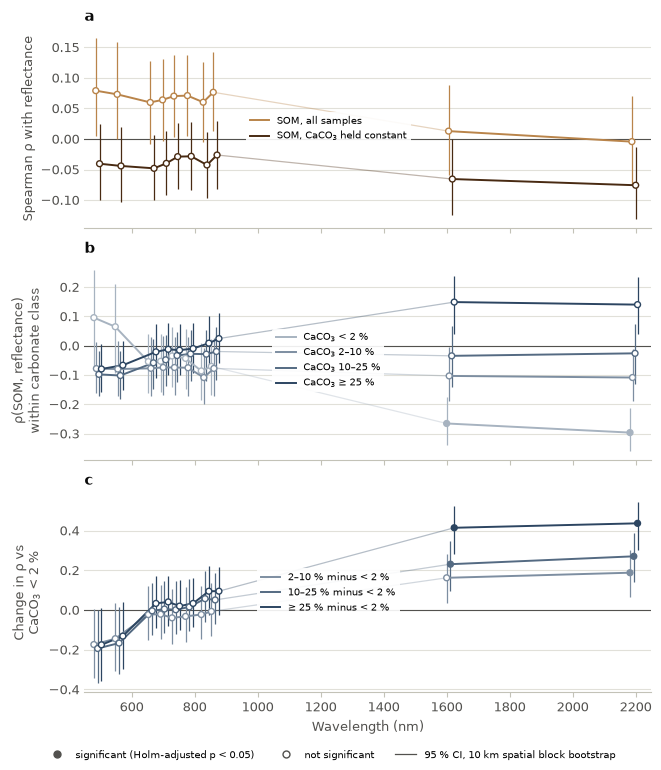

In [99]:
BLOCK_KM = 10  # spatial block size for the bootstrap
N_BOOT = 1000
ALPHA = 0.05

tested = carbonate.merge(samples[["uuid", "lon", "lat"]], on="uuid")
block_xy = gpd.GeoSeries(gpd.points_from_xy(tested["lon"], tested["lat"]), crs="EPSG:4326").to_crs(MOROCCO_LAEA)
block_cells = np.column_stack([block_xy.x // (BLOCK_KM * 1000), block_xy.y // (BLOCK_KM * 1000)]).astype(int)
_, block = np.unique(block_cells, axis=0, return_inverse=True)
block_members = [np.flatnonzero(block == b) for b in range(block.max() + 1)]
print(f"{len(tested):,} spectra in {len(block_members):,} blocks of {BLOCK_KM} km "
      f"(median {np.median([len(m) for m in block_members]):.0f} samples per block)")

reflectance = tested[band_columns].to_numpy()
som = tested["organic_matter_g_kg"].to_numpy()
caco3 = tested["caco3_pct_total"].to_numpy()
class_codes = tested["carbonate_class"].cat.codes.to_numpy()


def centred_ranks(values):
    ranks = pd.DataFrame(values).rank().to_numpy()
    return ranks - ranks.mean(axis=0)


def spearman_columns(values, target, control=None):
    """Spearman ρ of each column of `values` with `target`; partial ρ when a `control` is given.

    Pearson correlation of average ranks. With a control, the ranks of both sides first have their linear
    dependence on the control's rank removed, exactly as in Figure 7b.
    """
    rv, rt = centred_ranks(values), centred_ranks(target)[:, 0]
    if control is not None:
        rc = centred_ranks(control)[:, 0]
        rv = rv - np.outer(rc, rc @ rv / (rc @ rc))
        rt = rt - rc * (rc @ rt) / (rc @ rc)
    return rv.T @ rt / np.sqrt((rv**2).sum(axis=0) * (rt**2).sum())


def effect_profiles(rows):
    """Every quantity Figure 8 plots, per band, for one set of sample rows."""
    profiles = [spearman_columns(reflectance[rows], som[rows]),
                spearman_columns(reflectance[rows], som[rows], control=caco3[rows])]
    for code in range(len(CARBONATE_CLASS_LABELS)):
        in_class = rows[class_codes[rows] == code]
        profiles.append(spearman_columns(reflectance[in_class], som[in_class]))
    profiles = np.array(profiles)
    # Carbonate's effect on the SOM link: each class's ρ minus the < 2 % class's ρ.
    return np.vstack([profiles, profiles[3:] - profiles[2]])


PROFILE_NAMES = ["SOM", "SOM | CaCO3", *[f"within {label} %" for label in CARBONATE_CLASS_LABELS],
                 *[f"{label} % minus < 2 %" for label in CARBONATE_CLASS_LABELS[1:]]]
FAMILIES = {"a": slice(0, 2), "b": slice(2, 6), "c": slice(6, 9)}  # Holm correction runs within each panel

# Spatial block bootstrap: resample whole 10 km blocks, so neighbouring farms are not counted as independent.
rng = np.random.default_rng(0)
estimate = effect_profiles(np.arange(len(tested)))
replicates = np.array([
    effect_profiles(np.concatenate([block_members[i] for i in rng.integers(0, len(block_members), len(block_members))]))
    for _ in range(N_BOOT)
])
ci_low, ci_high = np.percentile(replicates, [2.5, 97.5], axis=0)
p_value = np.minimum(1, 2 * np.minimum((replicates <= 0).mean(axis=0), (replicates >= 0).mean(axis=0)))


def holm(p):
    """Holm step-down adjustment of a flat array of p-values."""
    order = np.argsort(p)
    adjusted = np.minimum(1, np.maximum.accumulate((p.size - np.arange(p.size)) * p[order]))
    return adjusted[np.argsort(order)]


p_adjusted = np.empty_like(p_value)
for family in FAMILIES.values():
    p_adjusted[family] = holm(p_value[family].ravel()).reshape(p_value[family].shape)
significant = p_adjusted < ALPHA

summary = pd.DataFrame(
    [[f"{e:+.2f}{'*' if s else ''} [{lo:+.2f}, {hi:+.2f}]" for e, s, lo, hi in zip(*row)]
     for row in zip(estimate, significant, ci_low, ci_high)],
    index=PROFILE_NAMES, columns=list(S2_BAND_CENTRES),
)
print(f"ρ [95 % block-bootstrap CI]; * = significant after Holm correction within each panel (α = {ALPHA})")
print(summary.to_string())


def draw_effect(ax, row, color, offset, label):
    """ρ per band with its 95 % interval; filled markers where significant, hollow where not."""
    x = wavelengths + offset
    for part in (vnir, ~vnir):
        ax.plot(x[part], estimate[row][part], color=color, lw=1.4, zorder=3, label=label if part is vnir else None)
    gap = [np.flatnonzero(vnir)[-1], np.flatnonzero(~vnir)[0]]
    ax.plot(x[gap], estimate[row][gap], color=color, lw=0.9, alpha=0.35, zorder=2)
    ax.errorbar(x, estimate[row], yerr=[estimate[row] - ci_low[row], ci_high[row] - estimate[row]], fmt="none",
                ecolor=color, elinewidth=0.9, capsize=0, zorder=2)
    ax.scatter(x, estimate[row], s=18, linewidth=1.0, edgecolor=color, zorder=4,
               facecolor=[color if s else "white" for s in significant[row]])


fig, (ax_all, ax_within, ax_contrast) = plt.subplots(3, 1, figsize=(6.5, 7.6), sharex=True, layout="constrained")
panels = [
    (ax_all, [(0, SOM_RAMP[1], "SOM, all samples"), (1, SOM_RAMP[-1], "SOM, CaCO$_3$ held constant")],
     "Spearman ρ with reflectance"),
    (ax_within, [(2 + i, color, f"CaCO$_3$ {label} %") for i, (label, color)
                 in enumerate(zip(CARBONATE_CLASS_LABELS, CARBONATE_RAMP))], "ρ(SOM, reflectance)\nwithin carbonate class"),
    (ax_contrast, [(6 + i, color, f"{label} % minus < 2 %") for i, (label, color)
                   in enumerate(zip(CARBONATE_CLASS_LABELS[1:], CARBONATE_RAMP[1:]))], "Change in ρ vs\nCaCO$_3$ < 2 %"),
]
for (ax, series, ylabel), letter in zip(panels, "abc"):
    offsets = np.linspace(-6, 6, len(series)) * (2 if len(series) > 2 else 1)  # side by side, not on top
    for (row, color, label), offset in zip(series, offsets):
        draw_effect(ax, row, color, offset, label)
    ax.axhline(0, color=INK_2, lw=0.8, zorder=1)
    ax.set_ylabel(ylabel)
    ax.set_title(letter, loc="left", fontweight="bold", color=INK)
    # The 865–1612 nm gap has no bands, so the legend sits there.
    ax.legend(loc="center", bbox_to_anchor=(0.43, 0.5), fontsize=7, frameon=True, framealpha=0.9, edgecolor="none")
ax_contrast.set_xlabel("Wavelength (nm)")
ax_contrast.set_xlim(450, 2250)
fig.legend(handles=[Line2D([], [], ls="", marker="o", markersize=5, color=INK_2),
                    Line2D([], [], ls="", marker="o", markersize=5, color=INK_2, markerfacecolor="white"),
                    Line2D([], [], color=INK_2, lw=0.9)],
           labels=[f"significant (Holm-adjusted p < {ALPHA})", "not significant",
                   f"95 % CI, {BLOCK_KM} km spatial block bootstrap"],
           loc="outside lower center", ncol=3, fontsize=7.5)

save(fig, "fig8_som_effect_significance")
plt.show()